----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

# Introducción
Este proyecto es para analizar los datos de 500 usuarios de la empresa Megaline, operador de telecomunicaciones, para su departamento comercial. Este departamento tiene la curiosidad de saber cuál de los planes tarifarios genera más ingresos, para tomar decisiones en el ajuste del presupuesto de publicidad. Se realizará la carga de datos de siempre, verificar si los tipos de datos son correctos y posteriormente hacer la limpia de datos si hay duplicados o errores en los datos. De acuerdo a los descubrimientos que se realicen se decidirá enriquecer los datos con cruce de tantos o realizando los "merge" necesarios para tener en un solo arreglo de datos la información con la que se va trabajar. Una vez teniendo los datos preparados se procede al analisis, graficando los datos necesarios donde el departamento tiene curiosidad de saber mensualemnte las llamadas, mensajes, y uso de internet que tienen los usuarios mensualmente y los ingresos que se tienen. Para tomar las desiciones pertinentes para el ajuste de presupuesto publicitario se harán pruebas de hipótesis.    

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv('../data/megaline_users.csv')
calls = pd.read_csv('../data/megaline_calls.csv')
messages = pd.read_csv('../data/megaline_messages.csv')
internet = pd.read_csv('../data/megaline_internet.csv')
plans = pd.read_csv('../data/megaline_plans.csv')
# Vista rápida
calls.head(), internet.head(), messages.head(), plans.head(), users.head()


(         id  user_id   call_date  duration
 0   1000_93     1000  2018-12-27      8.52
 1  1000_145     1000  2018-12-27     13.66
 2  1000_247     1000  2018-12-27     14.48
 3  1000_309     1000  2018-12-28      5.76
 4  1000_380     1000  2018-12-30      4.22,
          id  user_id session_date  mb_used
 0   1000_13     1000   2018-12-29    89.86
 1  1000_204     1000   2018-12-31     0.00
 2  1000_379     1000   2018-12-28   660.40
 3  1000_413     1000   2018-12-26   270.99
 4  1000_442     1000   2018-12-27   880.22,
          id  user_id message_date
 0  1000_125     1000   2018-12-27
 1  1000_160     1000   2018-12-31
 2  1000_223     1000   2018-12-31
 3  1000_251     1000   2018-12-27
 4  1000_255     1000   2018-12-26,
    messages_included  mb_per_month_included  minutes_included  \
 0                 50                  15360               500   
 1               1000                  30720              3000   
 
    usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_m

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Esta tabla presenta las tarifas que maneja cada plan tarifario. El tipo de dato de "plan_name" es object y debe ser string. 

## Corregir datos

Se corrige el tipo de datos del nombre de los planes tarifarios

In [5]:
plans['plan_name'] = plans['plan_name'].str.strip().str.capitalize()
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,Surf
1,1000,30720,3000,70,7,0.01,0.01,Ultimate


## Enriquecer los datos

Agregar la columna de "gb_per_month_include" para cada plan

In [6]:
plans['gb_per_month_include']= [15,30]
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_include
0,50,15360,500,20,10,0.03,0.03,Surf,15
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB


In [8]:
# Imprime una muestra de datos para usuarios
users.sample(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
118,1118,Deane,Ramirez,28,"Columbus, OH MSA",2018-12-08,surf,NaN
42,1042,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-01-15,surf,NaN
491,1491,Terina,Jensen,22,"Grand Rapids-Kentwood, MI MSA",2018-04-27,surf,2018-09-18
243,1243,Isaias,Compton,71,"Phoenix-Mesa-Chandler, AZ MSA",2018-05-11,surf,NaN
342,1342,Eugene,Patton,65,"Indianapolis-Carmel-Anderson, IN MSA",2018-10-21,surf,NaN



En este arreglo de datos nos muestra la información de los 500 usuarios para analizar. Al cargar el arreglo de datos los datos que son de tipo string y de fechas no se cargaron correctamente por lo tanto se tienen que corregir esos datos. En la columna de churn_date, tiene solo 34 valores no nulos esto es porque las fechas que estan registradas es cuando el usuario dejo de usar el servicio.  

### Corregir los datos

Se corrigen los datos de 'first_name', 'last_name', 'city', 'plan' a tipo string y para 'reg_date' y 'churn_date' a su tipo de dato datetime64[ns]

In [9]:
users['first_name'] = users['first_name'].astype('string')
users['last_name'] = users['last_name'].astype('string')
users['city'] = users['city'].astype('string')
users['plan'] = users['plan'].astype('string')

date_cols_users = ['reg_date', 'churn_date']
for c in date_cols_users:
    users[c] = pd.to_datetime(users[c], errors='coerce')

users.info()
users.sample(10)

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    string        
 2   last_name   500 non-null    string        
 3   age         500 non-null    int64         
 4   city        500 non-null    string        
 5   reg_date    500 non-null    datetime64[us]
 6   plan        500 non-null    string        
 7   churn_date  34 non-null     datetime64[us]
dtypes: datetime64[us](2), int64(2), string(4)
memory usage: 31.4 KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
413,1413,Andre,Hensley,38,"Bakersfield, CA MSA",2018-07-12,surf,NaT
483,1483,Miguel,Farrell,35,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-04-25,surf,NaT
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
12,1012,Jonelle,Mcbride,59,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-06-28,surf,2018-11-16
251,1251,Tifany,Mcgee,45,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-01,surf,NaT
234,1234,Matt,Taylor,19,"Seattle-Tacoma-Bellevue, WA MSA",2018-09-12,ultimate,NaT
180,1180,Wonda,Hays,24,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-12-01,surf,2018-12-22
428,1428,Asuncion,Conrad,66,"Phoenix-Mesa-Chandler, AZ MSA",2018-10-23,surf,NaT
101,1101,Sage,Conley,27,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-02-08,surf,NaT
283,1283,Alan,Burgess,38,"Charleston-North Charleston, SC MSA",2018-06-16,ultimate,NaT


### Enriquecer los datos


Se procede a analizar los usuarios, si no hay duplicados. Si los rangos de edad de los usuarios son de mayores de edad. 

In [10]:
print(users.duplicated(subset='user_id').sum())

0


Por lo tanto no hay usuarios duplicados 

In [11]:
print(users[~((users['age'] >= 18) & (users['age'] <= 100))])

Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []


Los usuarios estan dentro del rango de edades

In [12]:
#Normalizar planes 
users['plan'] = users['plan'].str.strip().str.capitalize()
users = users[users['plan'].isin(['Surf', 'Ultimate'])]
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,Ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,Surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,Surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,Surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,Surf,NaT


## Llamadas

In [13]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()



<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB


In [14]:
# Imprime una muestra de datos para las llamadas
calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Aqui esta el registro de llamadas de los usuarios de cuando se realizó la llamada y la duración. La columna 'call_date' necesita corregirse el tipo de datos a datetime64[ns]. La columna 'id' no es de gran relevancia corregir el tipo de dato, por que es la identificación. La duración debe redondearse a minutos enteros. 

### Corregir los datos

Se haces las correcciones de los datos en 'call_date' para que sea datetime64[ns]. Para la columna de 'duration', a dato entero. 

In [15]:
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')
calls['duration'] = np.ceil(calls['duration']).astype(int) #se redondeo los minutos 
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9
1,1000_145,1000,2018-12-27,14
2,1000_247,1000,2018-12-27,15
3,1000_309,1000,2018-12-28,6
4,1000_380,1000,2018-12-30,5


### Enriquecer los datos

Se crea la columna 'month' de tipo period[M], se van a contar el numero de seciones mensuales por usuario y sumar la duración de cada llamada para tener un total de minutos mensual de cada usuario que utilizó este servicio. De este modo será util los datos para los analisis que se necesitan. 

In [16]:
# Crear columna de mes (año-mes)
calls['month'] = calls['call_date'].dt.to_period('M')

# Agrupar por usuario y mes
calls_monthly = (
    calls.groupby(['user_id', 'month'])
    .agg(
        calls_count=('id', 'count'),      # número de llamadas
        total_minutes=('duration', 'sum') # minutos utilizados
    )
    .reset_index()
)

calls_monthly.info()
calls_monthly.head()

<class 'pandas.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   user_id        2258 non-null   int64    
 1   month          2258 non-null   period[M]
 2   calls_count    2258 non-null   int64    
 3   total_minutes  2258 non-null   int64    
dtypes: int64(3), period[M](1)
memory usage: 70.7 KB


,user_id,month,calls_count,total_minutes
0,1000,2018-12,16,124
1,1001,2018-08,27,182
2,1001,2018-09,49,315
3,1001,2018-10,65,393
4,1001,2018-11,64,426


## Mensajes

In [17]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()


<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [18]:
# Imprime una muestra de datos para los mensajes
messages.sample(5)


,id,user_id,message_date
61826,1385_290,1385,2018-07-28
42696,1280_215,1280,2018-08-16
34887,1222_100,1222,2018-10-10
65623,1422_28,1422,2018-12-13
6327,1055_445,1055,2018-10-17


Aqui esta el registro de mensajes de los usuarios. La columna 'message_date' necesita corregirse el tipo de datos a datetime64[ns]. La columna 'id' no es de gran relevancia corregir el tipo de dato, por que es la identificación del mensaje. 

### Corregir los datos

Se corrige el tipo de datos de 'message_date' de tipo datetime64[ns]

In [19]:
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

### Enriquecer los datos

Se crea la columna 'month' para registrar el conteo mensual de cantidad de mensajes de cada usuario. 

In [20]:
# Crear columna de mes (año-mes)
messages['month'] =messages['message_date'].dt.to_period('M')
# Agrupar por usuario y mes
messages_monthly = (
    messages.groupby(['user_id', 'month'])
    .agg(
        messages_count=('id', 'count'),      # número de mensajes
    )
    .reset_index()
)

messages_monthly.info()
messages_monthly.head()

<class 'pandas.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         1806 non-null   int64    
 1   month           1806 non-null   period[M]
 2   messages_count  1806 non-null   int64    
dtypes: int64(2), period[M](1)
memory usage: 42.5 KB


,user_id,month,messages_count
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


## Internet

In [21]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()


<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB


In [22]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(5)


,id,user_id,session_date,mb_used
97678,1460_306,1460,2018-06-29,403.73
82150,1384_390,1384,2018-10-04,0.00
33636,1153_112,1153,2018-09-03,742.73
934,1005_48,1005,2018-12-22,129.90
59128,1265_402,1265,2018-12-12,1021.94


Aqui esta el registro de uso de datos de internet de los usuarios. La columna 'session_date' necesita corregirse el tipo de datos a datetime64[ns]. La columna 'id' no es de gran relevancia corregir el tipo de dato, por que es la identificación de la sesión. 

### Corregir los datos

Se corrige el tipo de dato de 'session_date' a datetime64[ns]

In [23]:
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

### Enriquecer los datos

Se crea la columna 'month' para hacer el conteo mensual de del uso de megas de cada usuario. 

In [24]:
# Crear columna de mes (año-mes)
internet['month'] = internet['session_date'].dt.to_period('M')
# Agrupar por usuario y mes
internet_monthly = (
    internet.groupby(['user_id', 'month'])
    .agg(
        session_count=('id', 'count'),      # número de sesiones
        total_mb=('mb_used', 'sum') # datos utilizados
    )
    .reset_index()
)

internet_monthly.info()
internet_monthly.head()


<class 'pandas.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   user_id        2277 non-null   int64    
 1   month          2277 non-null   period[M]
 2   session_count  2277 non-null   int64    
 3   total_mb       2277 non-null   float64  
dtypes: float64(1), int64(2), period[M](1)
memory usage: 71.3 KB


,user_id,month,session_count,total_mb
0,1000,2018-12,5,1901.47
1,1001,2018-08,25,6919.15
2,1001,2018-09,53,13314.82
3,1001,2018-10,56,22330.49
4,1001,2018-11,51,18504.30


## Estudiar las condiciones de las tarifas

Se imprime la tabla de las tarifas para tenerlas presentes para el analisis. 

In [25]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_include
0,50,15360,500,20,10,0.03,0.03,Surf,15
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30


## Agregar datos por usuario

Ahora se tiene los datos mensuales de llamadas y su duración, mensajes y uso de internet de cada usuario mensualmente. 

In [26]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_monthly.head()


,user_id,month,calls_count,total_minutes
0,1000,2018-12,16,124
1,1001,2018-08,27,182
2,1001,2018-09,49,315
3,1001,2018-10,65,393
4,1001,2018-11,64,426


In [27]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls_monthly.head()


,user_id,month,calls_count,total_minutes
0,1000,2018-12,16,124
1,1001,2018-08,27,182
2,1001,2018-09,49,315
3,1001,2018-10,65,393
4,1001,2018-11,64,426


In [28]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_monthly.head()


,user_id,month,messages_count
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [29]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_monthly['total_mb'] = np.ceil(internet_monthly['total_mb']).astype(int)
internet_monthly.head()


,user_id,month,session_count,total_mb
0,1000,2018-12,5,1902
1,1001,2018-08,25,6920
2,1001,2018-09,53,13315
3,1001,2018-10,56,22331
4,1001,2018-11,51,18505


Se junta en una sola tabla el registro de cada usuario en el uso de cada servicio mensualmente. 

In [30]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Merge llamadas + mensajes
merged = pd.merge(
    calls_monthly,
    messages_monthly,
    on=['user_id', 'month'],
    how='outer'
)

# Merge con internet
merged = pd.merge(
    merged,
    internet_monthly,
    on=['user_id', 'month'],
    how='outer'
)

merged.info()
merged.head()

<class 'pandas.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2293 non-null   int64    
 1   month           2293 non-null   period[M]
 2   calls_count     2258 non-null   float64  
 3   total_minutes   2258 non-null   float64  
 4   messages_count  1806 non-null   float64  
 5   session_count   2277 non-null   float64  
 6   total_mb        2277 non-null   float64  
dtypes: float64(5), int64(1), period[M](1)
memory usage: 125.5 KB


,user_id,month,calls_count,total_minutes,messages_count,session_count,total_mb
0,1000,2018-12,16.0,124.0,11.0,5.0,1902.0
1,1001,2018-08,27.0,182.0,30.0,25.0,6920.0
2,1001,2018-09,49.0,315.0,44.0,53.0,13315.0
3,1001,2018-10,65.0,393.0,53.0,56.0,22331.0
4,1001,2018-11,64.0,426.0,36.0,51.0,18505.0


In [31]:
# Rellenar valores faltantes
num_cols = ['calls_count', 'total_minutes', 'messages_count', 'session_count', 'total_mb']
for col in num_cols:
    if col in merged.columns:
        merged[col] = merged[col].fillna(0)

# Ajustar tipos: int64 para contadores y minutos, float64 para MB
for col in ['calls_count', 'total_minutes', 'messages_count', 'session_count','total_mb']:
    if col in merged.columns:
        merged[col] = merged[col].astype('int64')
        
merged.info()
merged.head()

<class 'pandas.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   user_id         2293 non-null   int64    
 1   month           2293 non-null   period[M]
 2   calls_count     2293 non-null   int64    
 3   total_minutes   2293 non-null   int64    
 4   messages_count  2293 non-null   int64    
 5   session_count   2293 non-null   int64    
 6   total_mb        2293 non-null   int64    
dtypes: int64(6), period[M](1)
memory usage: 125.5 KB


,user_id,month,calls_count,total_minutes,messages_count,session_count,total_mb
0,1000,2018-12,16,124,11,5,1902
1,1001,2018-08,27,182,30,25,6920
2,1001,2018-09,49,315,44,53,13315
3,1001,2018-10,65,393,53,56,22331
4,1001,2018-11,64,426,36,51,18505


In [32]:
# Añade la información de la tarifa
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_include
0,50,15360,500,20,10,0.03,0.03,Surf,15
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30


Se crea un función para hacer un cruce de datos entre tablas para tener una tabla final, donde tendrá el registro mensual de cada usuario ya teniendo el calculo final de los ingresos que tuvo la empresa, restando los minutos, mensajes y megas que incluyen el plan tarifario Surf y Ultimate, para calcular los cobros extras. Con estos datos se puede tener el comportamiento mensual de los usuarios. 

In [33]:
# Calcula el ingreso mensual para cada usuario
def calc_monthly_revenue(usage_df, users_df, plans_df):
    """
    Calcula ingresos mensuales por usuario, según:
    - Tarifa fija mensual del plan
    - Exceso de minutos y SMS (costo por unidad)
    - Exceso de datos: se cobra por GB excedente, redondeando hacia arriba
    """
    df_u = users_df.copy()
    df_x = usage_df.copy()
    df_p = plans_df.copy()

    # Normaliza tipos de fecha y mes
    if not isinstance(df_x['month'].dtype, pd.PeriodDtype):
        # Convierte 'YYYY-MM' string o datetime -> Period[M]
        df_x['month'] = pd.PeriodIndex(df_x['month'].astype(str), freq='M')

    # Asegura datetime en users
    df_u['reg_date'] = pd.to_datetime(df_u['reg_date'], errors='coerce')
    df_u['churn_date'] = pd.to_datetime(df_u['churn_date'], errors='coerce')

    # Periodos mensuales para comparar actividad
    df_u['_reg_month'] = df_u['reg_date'].dt.to_period('M')
    df_u['_churn_month'] = df_u['churn_date'].dt.to_period('M')

    # Une usage con users (por user_id) y con plans (por plan)
    df = df_x.merge(df_u, on='user_id', how='left', validate='many_to_one')
    df = df.merge(df_p, left_on='plan', right_on='plan_name', how='left', validate='many_to_one')

    # Filtra meses fuera del periodo activo
    cond_active = (df['month'] >= df['_reg_month']) & (df['_reg_month'].notna())
    cond_churn = df['_churn_month'].isna() | (df['month'] <= df['_churn_month'])
    df = df[cond_active & cond_churn].copy()

    # Asegura columnas numéricas
    for col in ['total_minutes', 'messages_count', 'total_mb',
                'minutes_included', 'messages_included', 'mb_per_month_included',
                'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Cálculo de excedentes
    df['over_min'] = (df['total_minutes'] - df['minutes_included']).clip(lower=0)
    df['over_sms'] = (df['messages_count'] - df['messages_included']).clip(lower=0)

    # Datos excedentes en MB -> GB con redondeo hacia arriba
    df['over_mb'] = (df['total_mb'] - df['mb_per_month_included']).clip(lower=0)
    df['over_gb'] = np.where(df['over_mb'] > 0, np.ceil(df['over_mb'] / 1024.0), 0).astype(int)

    # Costos por excedente
    df['cost_min'] = df['over_min'] * df['usd_per_minute']
    df['cost_sms'] = df['over_sms'] * df['usd_per_message']
    df['cost_data'] = df['over_gb'] * df['usd_per_gb']

    # Ingresos totales
    df['ingresos_usd'] = df['usd_monthly_pay'] + df['cost_min'] + df['cost_sms'] + df['cost_data']

    # Selección de columnas de salida
    out_cols = [
        'user_id', 'first_name', 'last_name','city','plan', 'month',
        'total_minutes', 'messages_count', 'total_mb',
        'minutes_included', 'messages_included', 'mb_per_month_included',
        'over_min', 'over_sms', 'over_gb',
        'usd_per_minute', 'usd_per_message', 'usd_per_gb', 'usd_monthly_pay',
        'ingresos_usd'
    ]
    result = df[out_cols].sort_values(['user_id', 'month']).reset_index(drop=True)
    result['ingresos_usd'] = result['ingresos_usd'].round(2)

    return result


In [34]:
resultado = calc_monthly_revenue(merged,users,plans)
resultado.info()
resultado.head()

<class 'pandas.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   user_id                2256 non-null   int64    
 1   first_name             2256 non-null   string   
 2   last_name              2256 non-null   string   
 3   city                   2256 non-null   string   
 4   plan                   2256 non-null   object   
 5   month                  2256 non-null   period[M]
 6   total_minutes          2256 non-null   int64    
 7   messages_count         2256 non-null   int64    
 8   total_mb               2256 non-null   int64    
 9   minutes_included       2256 non-null   int64    
 10  messages_included      2256 non-null   int64    
 11  mb_per_month_included  2256 non-null   int64    
 12  over_min               2256 non-null   int64    
 13  over_sms               2256 non-null   int64    
 14  over_gb                2256 non-nul

,user_id,first_name,last_name,city,plan,month,total_minutes,messages_count,total_mb,minutes_included,messages_included,mb_per_month_included,over_min,over_sms,over_gb,usd_per_minute,usd_per_message,usd_per_gb,usd_monthly_pay,ingresos_usd
0,1000,Anamaria,Bauer,"Atlanta-Sandy Springs-Roswell, GA MSA",Ultimate,2018-12,124,11,1902,3000,1000,30720,0,0,0,0.01,0.01,7,70,70.00
1,1001,Mickey,Wilkerson,"Seattle-Tacoma-Bellevue, WA MSA",Surf,2018-08,182,30,6920,500,50,15360,0,0,0,0.03,0.03,10,20,20.00
2,1001,Mickey,Wilkerson,"Seattle-Tacoma-Bellevue, WA MSA",Surf,2018-09,315,44,13315,500,50,15360,0,0,0,0.03,0.03,10,20,20.00
3,1001,Mickey,Wilkerson,"Seattle-Tacoma-Bellevue, WA MSA",Surf,2018-10,393,53,22331,500,50,15360,0,3,7,0.03,0.03,10,20,90.09
4,1001,Mickey,Wilkerson,"Seattle-Tacoma-Bellevue, WA MSA",Surf,2018-11,426,36,18505,500,50,15360,0,0,4,0.03,0.03,10,20,60.00


## Estudia el comportamiento de usuario



Se llega a la parte interesante la estadística descriptiva sobre los datos que se prepararon y fusionaron. Se graficaran graficas de barras para representar el comportamiento de los usuarios por plan tarifario, Surf y Ultimate de manera mensual. Estas gáficas serán por el servicio de llamadas, mensajes e internet, para tener un panorama general del comportamiento de los usuarios en los servicios que mas consumen. También se graficarán histogramas para observar e identificar que distribución tienen los datos.  

### Llamadas

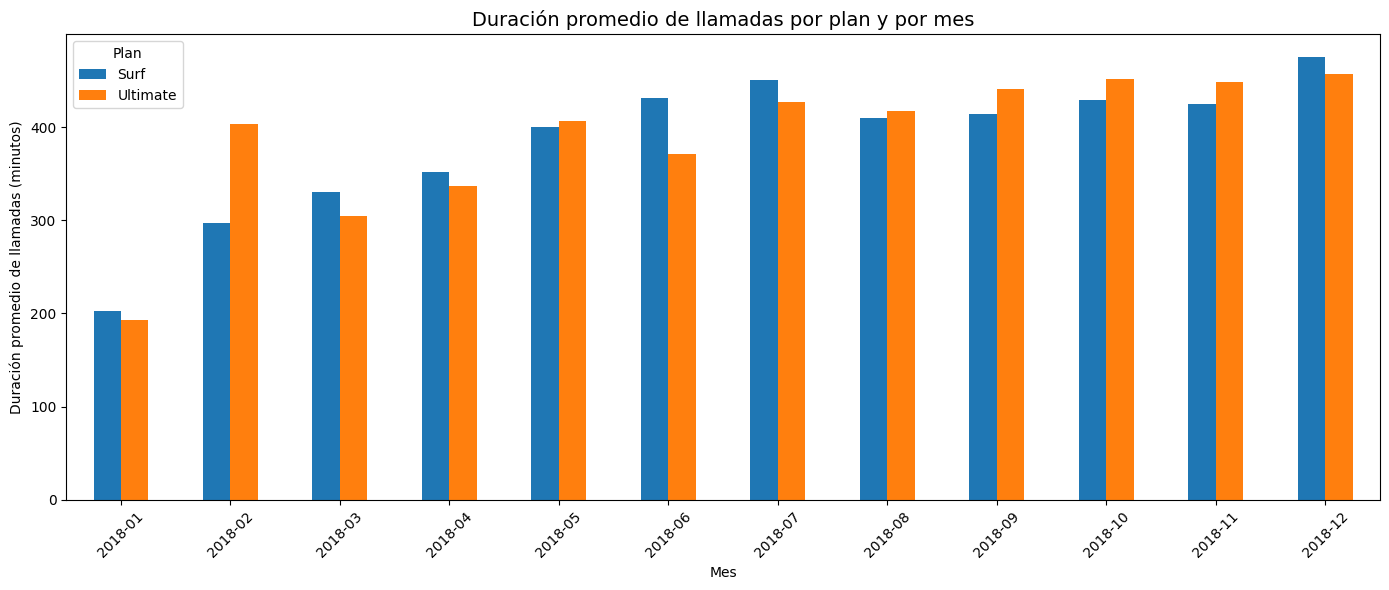

In [35]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Agrupar por plan y mes
avg_minutes = resultado.groupby(['month', 'plan'])['total_minutes'].mean().unstack()

# Graficar como barras agrupadas
avg_minutes.plot(kind='bar', figsize=(14,6))

# Etiquetas y título
plt.title("Duración promedio de llamadas por plan y por mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Duración promedio de llamadas (minutos)")
plt.xticks(rotation=45)
plt.legend(title="Plan")
plt.tight_layout()
plt.show()


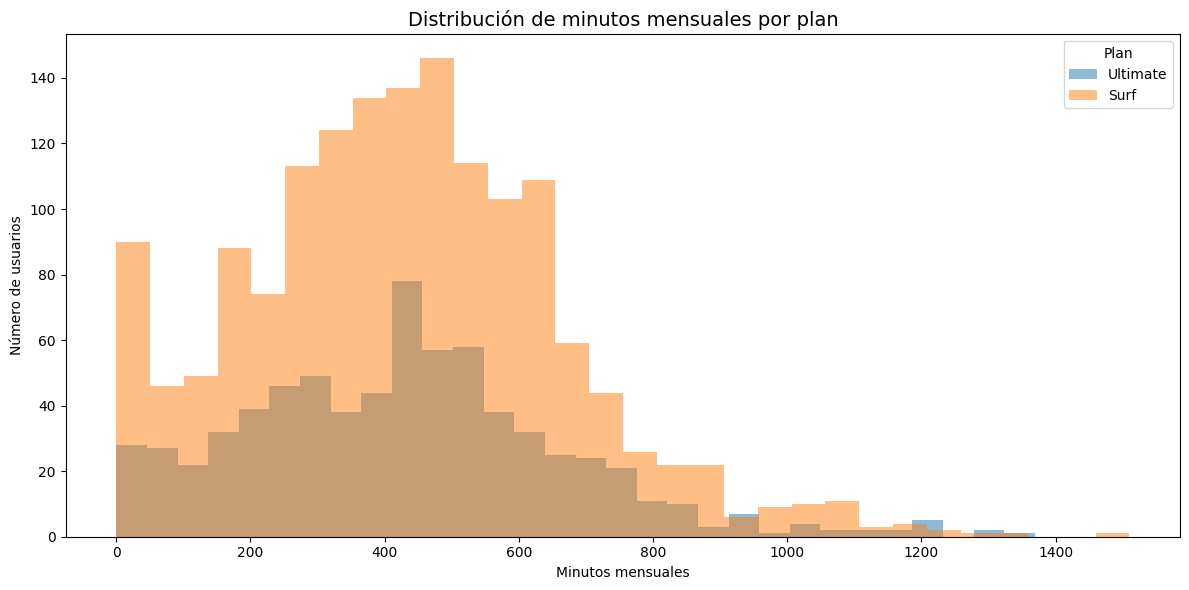

In [36]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# Separar los datos por plan
plans = resultado['plan'].unique()

plt.figure(figsize=(12,6))

for plan in plans:
    subset = resultado[resultado['plan'] == plan]['total_minutes']
    plt.hist(subset, bins=30, alpha=0.5, label=plan)

# Etiquetas y título
plt.title("Distribución de minutos mensuales por plan", fontsize=14)
plt.xlabel("Minutos mensuales")
plt.ylabel("Número de usuarios")
plt.legend(title="Plan")
plt.tight_layout()
plt.show()


In [37]:
# Calcula la media y la varianza de la duración mensual de llamadas.
# Media

media_minutos_surf = resultado[resultado['plan'] == 'Surf']['total_minutes'].mean()
media_minutos_ultimate = resultado[resultado['plan'] == 'Ultimate']['total_minutes'].mean()
# Varianza
varianza_minutos_surf = resultado[resultado['plan'] == 'Surf']['total_minutes'].var()
varianza_minutos_ultimate = resultado[resultado['plan'] == 'Ultimate']['total_minutes'].var()

print(f"Media de duración mensual de llamadas en usuarios Surf: {media_minutos_surf:.2f} minutos")
print(f"Media de duración mensual de llamadas en usuarios Ultimate: {media_minutos_ultimate:.2f} minutos")
print(f"Varianza de duración mensual de llamadas en usuarios Surf: {varianza_minutos_surf:.2f}")
print(f"Varianza de duración mensual de llamadas en usuarios Ultimate: {varianza_minutos_ultimate:.2f}")


Media de duración mensual de llamadas en usuarios Surf: 428.80 minutos
Media de duración mensual de llamadas en usuarios Ultimate: 430.15 minutos
Varianza de duración mensual de llamadas en usuarios Surf: 55334.74
Varianza de duración mensual de llamadas en usuarios Ultimate: 58068.41


<Figure size 800x600 with 0 Axes>

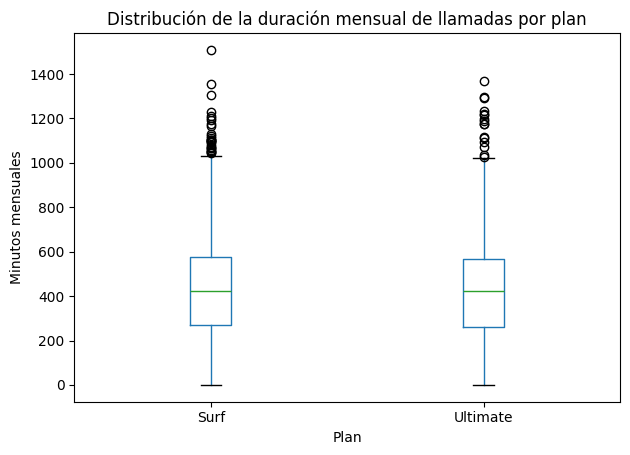

In [38]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
# Crear boxplot por plan
plt.figure(figsize=(8,6))
resultado.boxplot(column='total_minutes', by='plan', grid=False)

# Títulos y etiquetas
plt.title("Distribución de la duración mensual de llamadas por plan")
plt.suptitle("")  # elimina el título automático de pandas
plt.xlabel("Plan")
plt.ylabel("Minutos mensuales")
plt.tight_layout()
plt.show()


Parece un comportamiento muy similar en los usuarios de cada plan. Sin embargo los de la tarifa Surf hay varios usuarios que pasan de su límite de minutos mensual, la media no sobrepasa el limite mensual de la tarifa Surf. Hay más cantidad de usuario con el plan Surf que el plan tarifario Ultimate. Sin embargo tienen una diferencia entre varianzas de 2733.67. 

### Mensajes

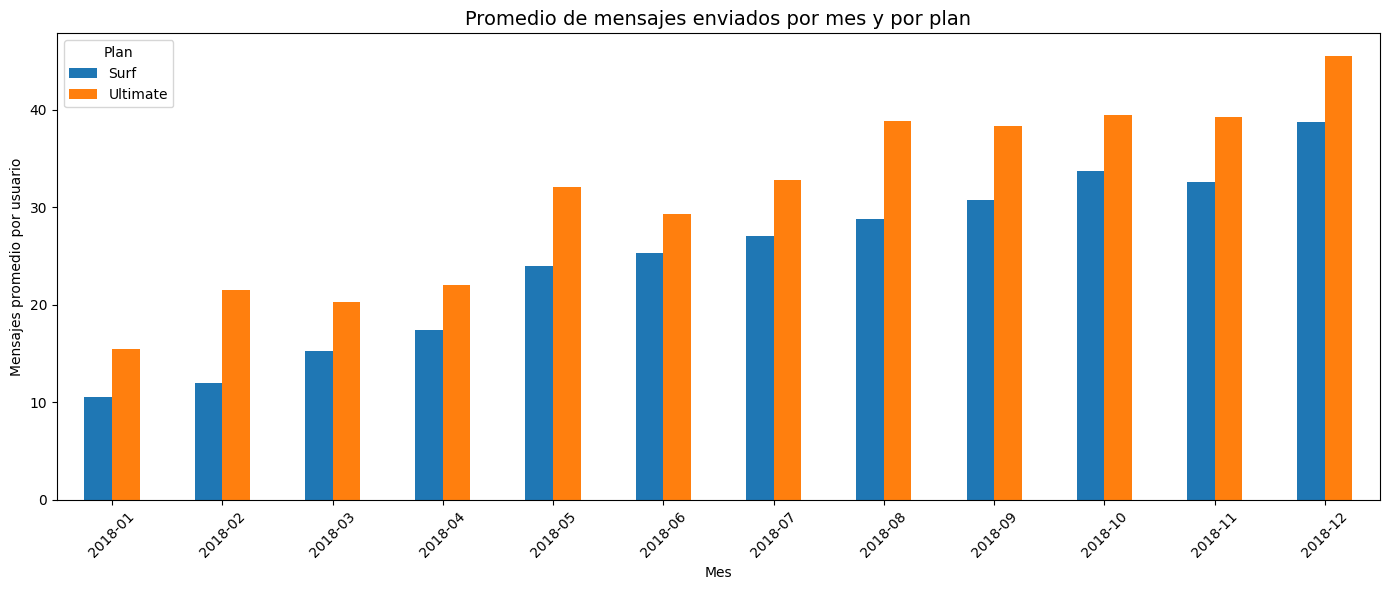

In [39]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
# Agrupar por mes y plan -> promedio de mensajes
avg_messages = resultado.groupby(['month', 'plan'])['messages_count'].mean().unstack()

# Gráfico de barras agrupadas
avg_messages.plot(kind='bar', figsize=(14,6))

# Etiquetas y título
plt.title("Promedio de mensajes enviados por mes y por plan", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Mensajes promedio por usuario")
plt.xticks(rotation=45)
plt.legend(title="Plan")
plt.tight_layout()
plt.show()


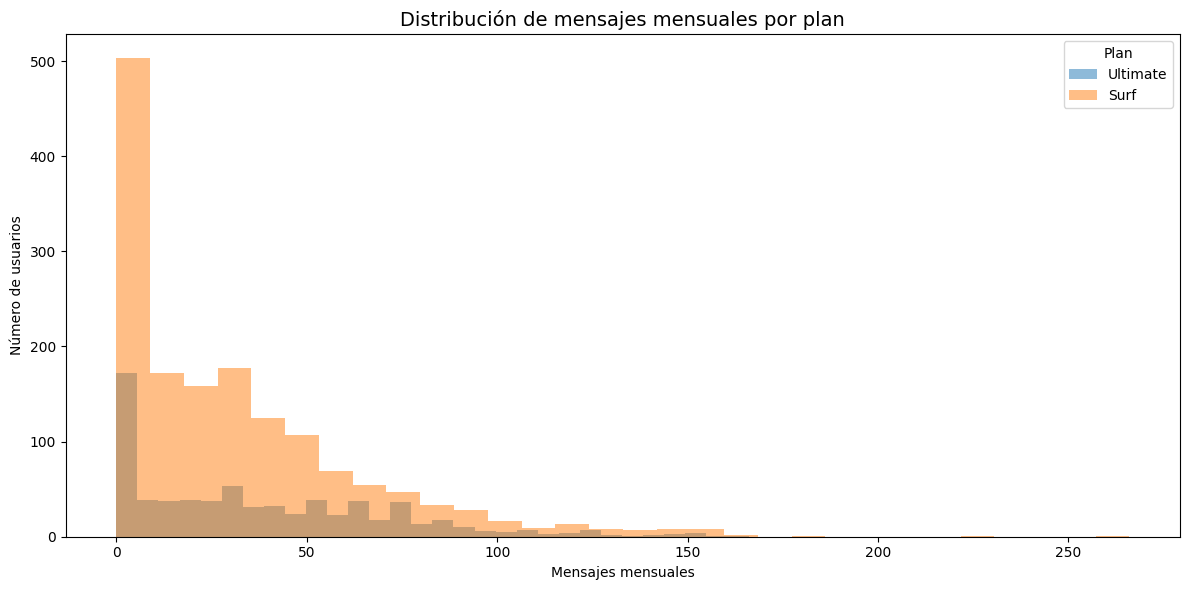

In [40]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
plans = resultado['plan'].unique()

plt.figure(figsize=(12,6))

for plan in plans:
    subset = resultado[resultado['plan'] == plan]['messages_count']
    plt.hist(subset, bins=30, alpha=0.5, label=plan)

# Etiquetas y título
plt.title("Distribución de mensajes mensuales por plan", fontsize=14)
plt.xlabel("Mensajes mensuales")
plt.ylabel("Número de usuarios")
plt.legend(title="Plan")
plt.tight_layout()
plt.show()


In [41]:
# Media
media_mensajes_surf = resultado[resultado['plan'] == 'Surf']['messages_count'].mean()
media_mensajes_ultimate = resultado[resultado['plan'] == 'Ultimate']['messages_count'].mean()
# Varianza
varianza_mensajes_surf = resultado[resultado['plan'] == 'Surf']['messages_count'].var()
varianza_mensajes_ultimate = resultado[resultado['plan'] == 'Ultimate']['messages_count'].var()

print(f"Media de duración mensual de mensajes en usuarios Surf: {media_mensajes_surf:.2f} mensajes")
print(f"Media de duración mensual de mensajes en usuarios Ultimate: {media_mensajes_ultimate:.2f} mensajes")
print(f"Varianza de duración mensual de mensajes en usuarios Surf: {varianza_mensajes_surf:.2f}")
print(f"Varianza de duración mensual de mensajes en usuarios Ultimate: {varianza_mensajes_ultimate:.2f}")

Media de duración mensual de mensajes en usuarios Surf: 31.11 mensajes
Media de duración mensual de mensajes en usuarios Ultimate: 37.80 mensajes
Varianza de duración mensual de mensajes en usuarios Surf: 1131.72
Varianza de duración mensual de mensajes en usuarios Ultimate: 1217.73


<Figure size 800x600 with 0 Axes>

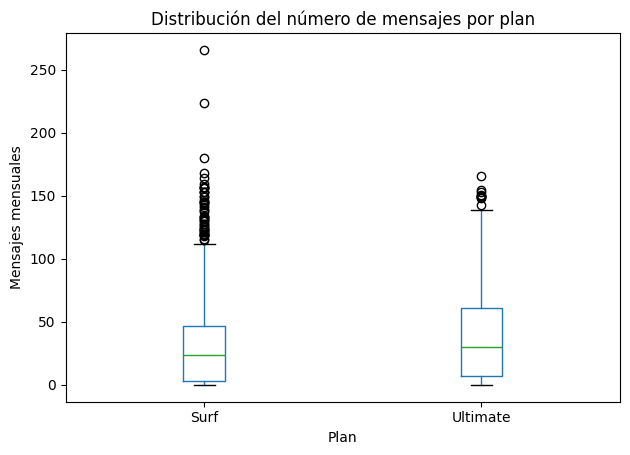

In [42]:
plt.figure(figsize=(8,6))
resultado.boxplot(column='messages_count', by='plan', grid=False)

# Títulos y etiquetas
plt.title("Distribución del número de mensajes por plan")
plt.suptitle("")  # elimina el título automático de pandas
plt.xlabel("Plan")
plt.ylabel("Mensajes mensuales")
plt.tight_layout()
plt.show()

En uso de mensajes en ambos planes presentan los usuarios un comportamiento similar, en su media con una diferencia de 8 mensajes aproximadamente y en la varianza hay una diferencia de 86.01. En la grafica de baras se puede notar que hay un aumento de mensajes en el mes de diciembre lo que puede interpretarse que por las fechas decembrinas los usuarios mandan mas mensajes. Hay varios usuarios Surf que sobrepasan el límite de mesajes de paquete tarifario. 

### Internet

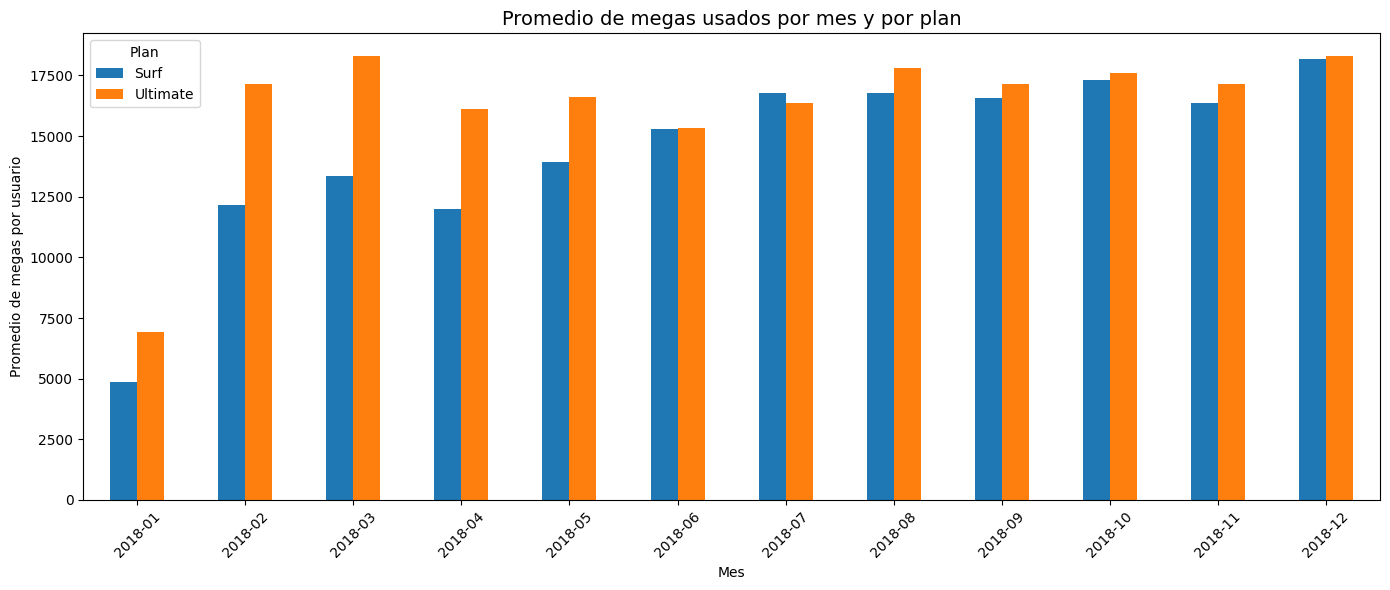

In [43]:
# Agrupar por mes y plan -> promedio de megas
avg_megas = resultado.groupby(['month', 'plan'])['total_mb'].mean().unstack()

# Gráfico de barras agrupadas
avg_megas.plot(kind='bar', figsize=(14,6))

# Etiquetas y título
plt.title("Promedio de megas usados por mes y por plan", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Promedio de megas por usuario")
plt.xticks(rotation=45)
plt.legend(title="Plan")
plt.tight_layout()
plt.show()

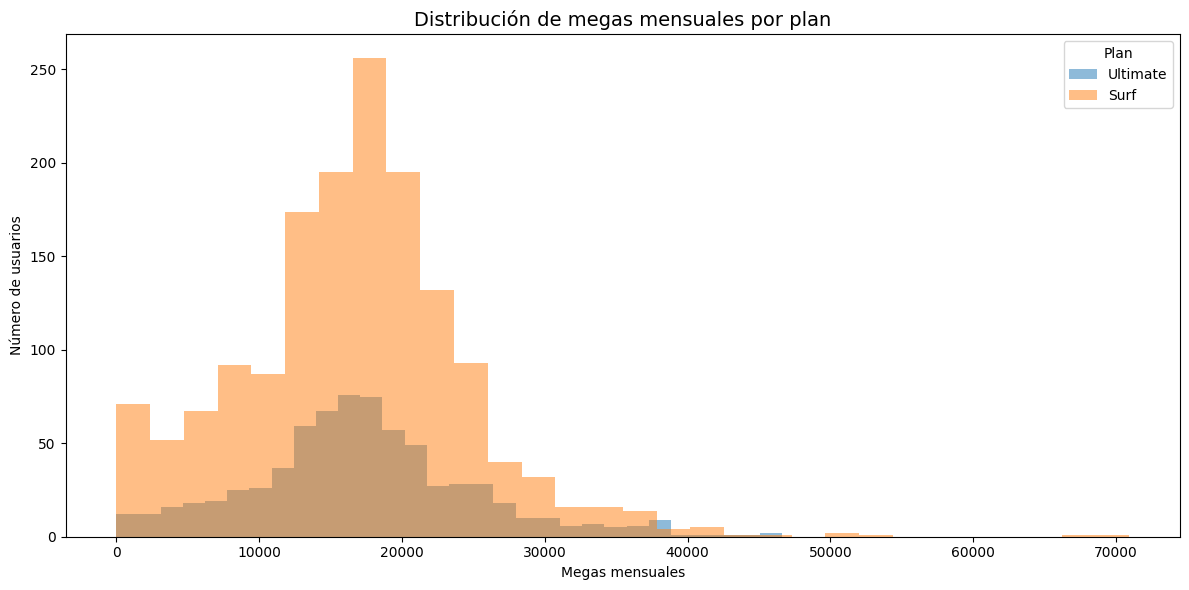

In [44]:
plans = resultado['plan'].unique()

plt.figure(figsize=(12,6))

for plan in plans:
    subset = resultado[resultado['plan'] == plan]['total_mb']
    plt.hist(subset, bins=30, alpha=0.5, label=plan)

# Etiquetas y título
plt.title("Distribución de megas mensuales por plan", fontsize=14)
plt.xlabel("Megas mensuales")
plt.ylabel("Número de usuarios")
plt.legend(title="Plan")
plt.tight_layout()
plt.show()

In [45]:

# Media
media_megas_surf = resultado[resultado['plan'] == 'Surf']['total_mb'].mean()
media_megas_ultimate = resultado[resultado['plan'] == 'Ultimate']['total_mb'].mean()
# Varianza
varianza_megas_surf = resultado[resultado['plan'] == 'Surf']['total_mb'].var()
varianza_megas_ultimate = resultado[resultado['plan'] == 'Ultimate']['total_mb'].var()

print(f"Media de uso mensual de megas en usuarios Surf: {media_megas_surf:.2f} megas")
print(f"Media de uso mensual de megas en usuarios Ultimate: {media_megas_ultimate:.2f} megas")
print(f"Varianza de uso mensual de megas en usuarios Surf: {varianza_megas_surf:.2f}")
print(f"Varianza de uso mensual de megas en usuarios Ultimate: {varianza_megas_ultimate:.2f}")


Media de uso mensual de megas en usuarios Surf: 16560.80 megas
Media de uso mensual de megas en usuarios Ultimate: 17242.92 megas
Varianza de uso mensual de megas en usuarios Surf: 64104335.09
Varianza de uso mensual de megas en usuarios Ultimate: 62148699.58


<Figure size 800x600 with 0 Axes>

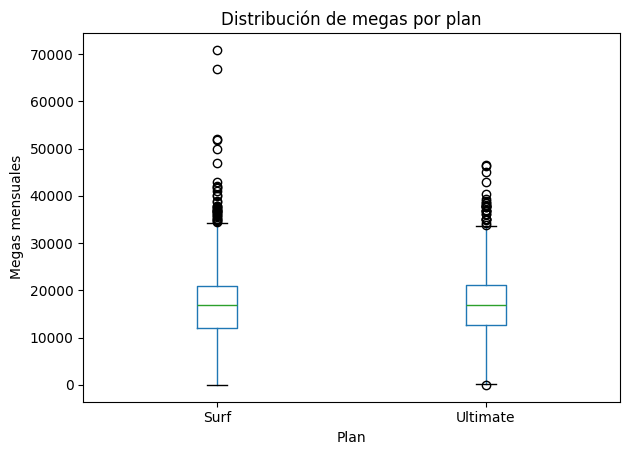

In [46]:
plt.figure(figsize=(8,6))
resultado.boxplot(column='total_mb', by='plan', grid=False)

# Títulos y etiquetas
plt.title("Distribución de megas por plan")
plt.suptitle("")  # elimina el título automático de pandas
plt.xlabel("Plan")
plt.ylabel("Megas mensuales")
plt.tight_layout()
plt.show()

En promedio no varia el comportamiento de uso del internet entre planes tarifarios, sin embargo los usuarios del plan Surf son los que parecen que mas consumen datos y pasan su limite. 

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

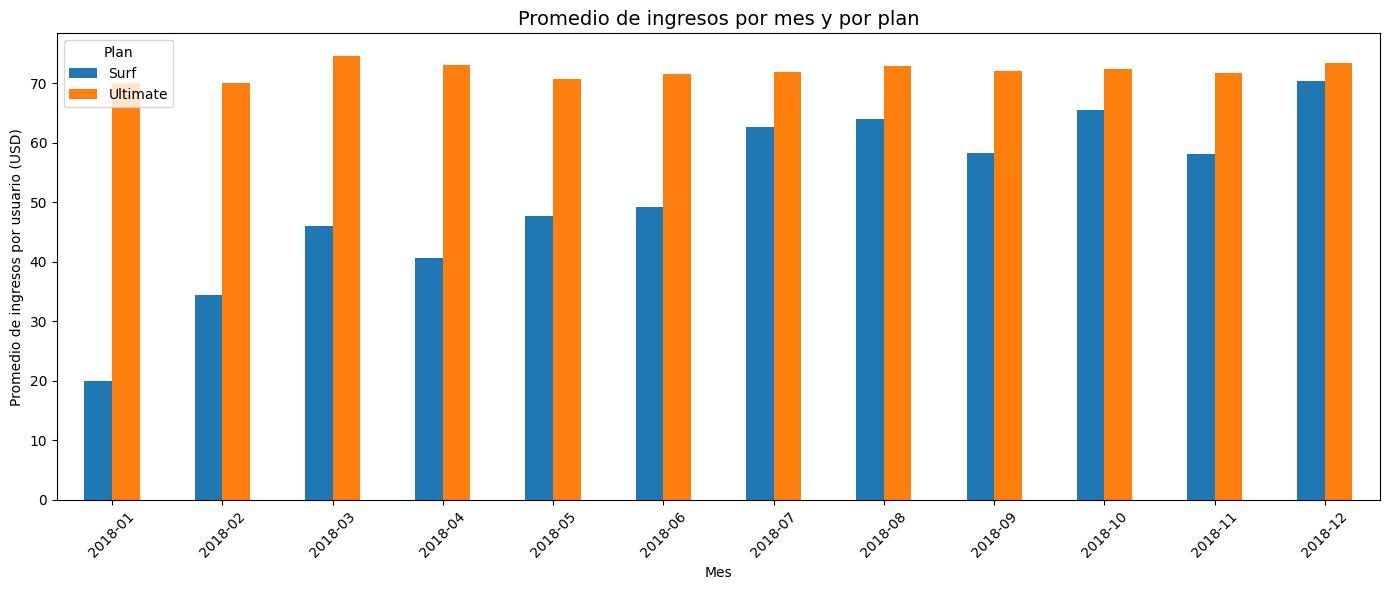

In [47]:
# Agrupar por mes y plan -> promedio de ingresos
avg_ingreso = resultado.groupby(['month', 'plan'])['ingresos_usd'].mean().unstack()

# Gráfico de barras agrupadas
avg_ingreso.plot(kind='bar', figsize=(14,6))

# Etiquetas y título
plt.title("Promedio de ingresos por mes y por plan", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Promedio de ingresos por usuario (USD)")
plt.xticks(rotation=45)
plt.legend(title="Plan")
plt.tight_layout()
plt.show()

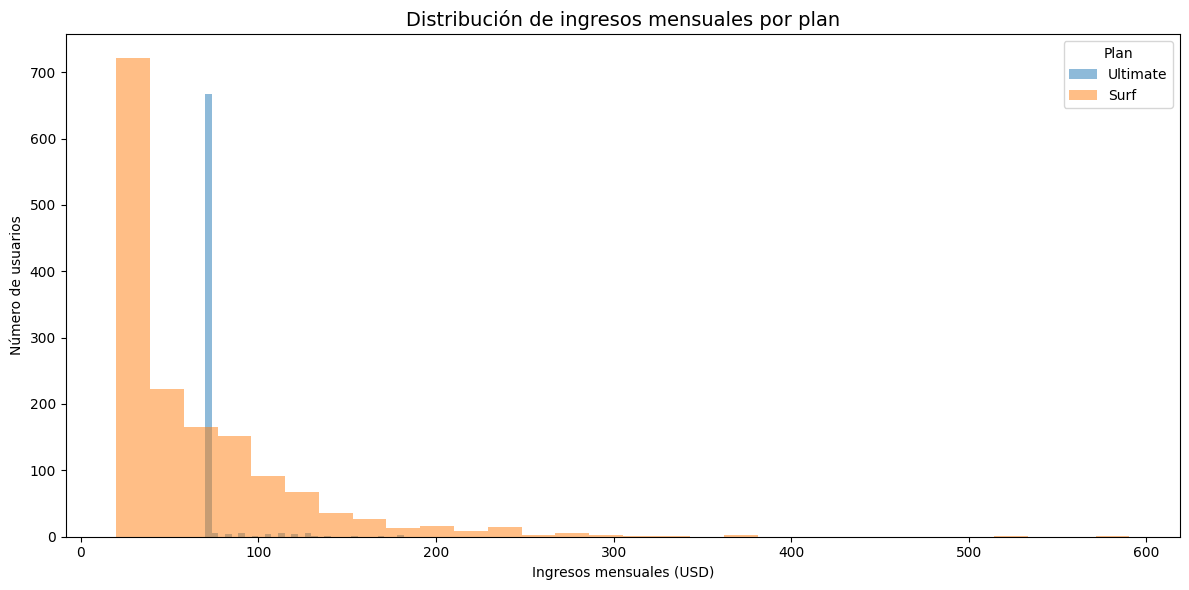

In [48]:
plans = resultado['plan'].unique()

plt.figure(figsize=(12,6))

for plan in plans:
    subset = resultado[resultado['plan'] == plan]['ingresos_usd']
    plt.hist(subset, bins=30, alpha=0.5, label=plan)

# Etiquetas y título
plt.title("Distribución de ingresos mensuales por plan", fontsize=14)
plt.xlabel("Ingresos mensuales (USD)")
plt.ylabel("Número de usuarios")
plt.legend(title="Plan")
plt.tight_layout()
plt.show()

In [49]:
# Media
media_usd_surf = resultado[resultado['plan'] == 'Surf']['ingresos_usd'].mean()
media_usd_ultimate = resultado[resultado['plan'] == 'Ultimate']['ingresos_usd'].mean()
# Varianza
varianza_usd_surf = resultado[resultado['plan'] == 'Surf']['ingresos_usd'].var()
varianza_usd_ultimate = resultado[resultado['plan'] == 'Ultimate']['ingresos_usd'].var()

print(f"Media de ingreso mensual en usuarios Surf: {media_usd_surf:.2f} USD")
print(f"Media de ingreso mensual en usuarios Ultimate: {media_usd_ultimate:.2f} USD")
print(f"Varianza de ingreso mensual en usuarios Surf: {varianza_usd_surf:.2f}")
print(f"Varianza de ingreso mensual en usuarios Ultimate: {varianza_usd_ultimate:.2f}")


Media de ingreso mensual en usuarios Surf: 60.65 USD
Media de ingreso mensual en usuarios Ultimate: 72.35 USD
Varianza de ingreso mensual en usuarios Surf: 3063.94
Varianza de ingreso mensual en usuarios Ultimate: 131.96


<Figure size 800x600 with 0 Axes>

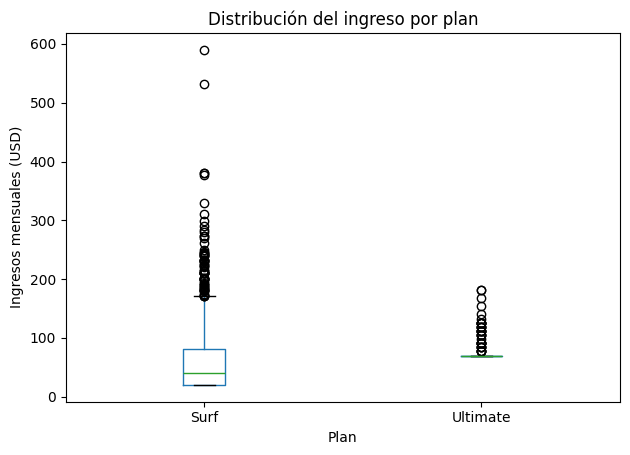

In [50]:
plt.figure(figsize=(8,6))
resultado.boxplot(column='ingresos_usd', by='plan', grid=False)

# Títulos y etiquetas
plt.title("Distribución del ingreso por plan")
plt.suptitle("")  # elimina el título automático de pandas
plt.xlabel("Plan")
plt.ylabel("Ingresos mensuales (USD)")
plt.tight_layout()
plt.show()

En el ingreso se puede observar una diferencia marcada entre planes. El plan que genera más ingresos es el Surf por lo usuarios que pasan sus limites y pagan extra, a comparación de del plan Ultimate que solo genera ingresos de casi 200 USD mensules, los usuarios surf pueden llegar a pagar casi 600 USD mensual por los extras de sus servicios. 

## Prueba las hipótesis estadísticas

In [51]:
# Prueba las hipótesis
# Separar los ingresos por plan
ingresos_ultimate = resultado[resultado['plan'] == 'Ultimate']['ingresos_usd']
ingresos_surf = resultado[resultado['plan'] == 'Surf']['ingresos_usd']

# Prueba t de Student (asumiendo varianzas desiguales)
t_stat, p_value = st.ttest_ind(ingresos_ultimate, ingresos_surf, equal_var=False)

print(f"Estadístico t: {t_stat:.3f}")
print(f"Valor p: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: Los ingresos promedio difieren significativamente entre los planes.")
else:
    print("No rechazamos H0: No hay evidencia suficiente para afirmar que los ingresos difieren.")


Estadístico t: 7.952
Valor p: 3.1993972641701262e-15
Rechazamos H0: Los ingresos promedio difieren significativamente entre los planes.


In [52]:
# Prueba las hipótesis
# Separar ingresos según región
ingresos_ny_nj = resultado[resultado['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingresos_usd']
ingresos_otros = resultado[resultado['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingresos_usd']

# Prueba t de Student (varianzas desiguales)
t_stat, p_value = st.ttest_ind(ingresos_ny_nj, ingresos_otros, equal_var=False)

print(f"Estadístico t: {t_stat:.3f}")
print(f"Valor p: {p_value:.5f}")


alpha = 0.03
if p_value < alpha:
    print("Rechazamos H0: El ingreso promedio de los usuarios de NY-NJ es significativamente diferente al de otras regiones.")
else:
    print("No rechazamos H0: No hay evidencia suficiente para afirmar que los ingresos difieren entre NY-NJ y otras regiones.")


Estadístico t: -2.089
Valor p: 0.03718
No rechazamos H0: No hay evidencia suficiente para afirmar que los ingresos difieren entre NY-NJ y otras regiones.


In [53]:
print(resultado['city'].value_counts())

city
New York-Newark-Jersey City, NY-NJ-PA MSA          371
Los Angeles-Long Beach-Anaheim, CA MSA             129
Chicago-Naperville-Elgin, IL-IN-WI MSA              93
Dallas-Fort Worth-Arlington, TX MSA                 88
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA     82
                                                  ... 
Stockton, CA MSA                                     4
Omaha-Council Bluffs, NE-IA MSA                      3
Jacksonville, FL MSA                                 2
El Paso, TX MSA                                      2
Cape Coral-Fort Myers, FL MSA                        1
Name: count, Length: 72, dtype: Int64


## Conclusión general

De acuerdo a los resultados obtenidos se puede concluir que los usuarios del Plan Surf a pesar de ser el plan tarifario "económico" pueden llegar a pagar más mensualmente por los extras y esto se traduce a mayor ingresos para la empresa. De acuerdo a esto se puede proponer al departamento comercial hacer más promoción al Plan Surf como plan estrella y al Plan Ultimate ofrecerlo como un plan tarifario para usuarios "leales" de acuerdo a su atiguedad y el uso de servicios.   